# G3 AIOps Incident Analysis

This notebook is the narrative layer for the lab submission. It calls the reusable script pipeline instead of duplicating detector logic, then inspects the generated evidence for WHEN / WHERE / WHAT.

## 1. Run Automated Pipeline

The source of truth is `scripts/run_pipeline.py`. Running it rebuilds validation output, cart-service features, anomaly detection results, log pattern counts, correlation timeline, figures, and findings.

In [1]:
import subprocess
from pathlib import Path

root = Path.cwd()
if not (root / 'scripts/run_pipeline.py').exists():
    root = root.parent

subprocess.run(
    [
        'python3',
        'scripts/run_pipeline.py',
        '--data-dir',
        'g3-data/g3',
        '--output-dir',
        'reports/generated',
        '--figures-dir',
        'reports/figures',
        '--docs-asset-dir',
        'docs/assets/g3',
        '--findings-path',
        'FINDINGS.md',
        '--submit-path',
        'SUBMIT.md',
    ],
    cwd=root,
    check=True,
)

Pipeline completed
Cart metric rows: 2820
Pattern log events: 6430
Earliest cache warning line: 4235
Evidence summary: reports/generated/g3_evidence_summary.json
Final findings: FINDINGS.md
Submission template: SUBMIT.md


CompletedProcess(args=['python3', 'scripts/run_pipeline.py', '--data-dir', 'g3-data/g3', '--output-dir', 'reports/generated', '--figures-dir', 'reports/figures', '--docs-asset-dir', 'docs/assets/g3', '--findings-path', 'FINDINGS.md', '--submit-path', 'SUBMIT.md'], returncode=0)

## 2. Load Evidence Summary

In [2]:
import json

import pandas as pd

summary = json.loads((root / 'reports/generated/g3_evidence_summary.json').read_text())
summary

{'source_files': {'cart_metrics': 'g3-data/g3/metrics/cart-service.csv',
  'cart_logs': 'g3-data/g3/logs/cart-service.log.jsonl'},
 'rows': {'cart_metrics': 2820, 'cart_pattern_logs': 6430},
 'log_pattern_counts': {'cache_eviction_failed': 2645,
  'gc_overhead': 2069,
  'oom_imminent': 875,
  'oom_killed': 841},
 'log_pattern_first_occurrence': {'cache_eviction_failed': {'timestamp': '2026-06-01T06:30:08.687Z',
   'line': 4235,
   'message': 'ProductCatalogCache eviction failed: heap pressure too high',
   'pod': 'cart-service-7d9f8b-y6dpb'},
  'gc_overhead': {'timestamp': '2026-06-01T06:31:52.777Z',
   'line': 4261,
   'message': 'GC overhead limit warning: pause=551ms heap=99%',
   'pod': 'cart-service-7d9f8b-hsahx'},
  'oom_killed': {'timestamp': '2026-06-01T19:59:02.347Z',
   'line': 17743,
   'message': 'Container OOMKilled: memory limit exceeded',
   'pod': 'cart-service-7d9f8b-thv3a'},
  'oom_imminent': {'timestamp': '2026-06-01T19:59:15.571Z',
   'line': 17748,
   'message': 'O

## 3. Detector Comparison

Z-score and EWMA are the explainable univariate memory detectors. Isolation Forest is multivariate and uses memory, GC, latency, 5xx, and restart count. Log analysis uses fixed pattern extraction, not Drain3.

In [3]:
detectors = pd.read_csv(root / 'reports/generated/detector_comparison.csv')
detectors

,detector,rule,anomaly_points
0,Rolling Z-score,abs(memory_mb rolling z-score) > 3,21
1,EWMA,abs(memory_mb ewma_score span=120) > 3,5
2,Isolation Forest,"multivariate score over memory_pct, GC, latenc...",226


## 4. First Log Pattern Occurrences

In [4]:
firsts = pd.DataFrame.from_dict(summary['log_pattern_first_occurrence'], orient='index')
firsts[['timestamp', 'line', 'pod', 'message']]

,timestamp,line,pod,message
cache_eviction_failed,2026-06-01T06:30:08.687Z,4235,cart-service-7d9f8b-y6dpb,ProductCatalogCache eviction failed: heap pres...
gc_overhead,2026-06-01T06:31:52.777Z,4261,cart-service-7d9f8b-hsahx,GC overhead limit warning: pause=551ms heap=99%
oom_killed,2026-06-01T19:59:02.347Z,17743,cart-service-7d9f8b-thv3a,Container OOMKilled: memory limit exceeded
oom_imminent,2026-06-01T19:59:15.571Z,17748,cart-service-7d9f8b-thv3a,OutOfMemoryError imminent: available heap < 5%


## 5. Anomaly Samples

Inspect rows where any detector fired.

In [5]:
anomalies = pd.read_csv(root / 'reports/generated/anomalies.csv', parse_dates=['timestamp'])
anomaly_rows = anomalies[anomalies[['z_anomaly', 'ewma_anomaly', 'if_anomaly']].any(axis=1)]
anomaly_rows[['timestamp', 'memory_mb', 'memory_pct', 'jvm_gc_pause_ms_avg', 'http_p99_latency_ms', 'http_5xx_rate', 'container_restart_count', 'z_anomaly', 'ewma_anomaly', 'if_anomaly']].head(20)

,timestamp,memory_mb,memory_pct,jvm_gc_pause_ms_avg,http_p99_latency_ms,http_5xx_rate,container_restart_count,z_anomaly,ewma_anomaly,if_anomaly
247,2026-06-01 02:03:30+00:00,487.564016,23.806837,45.3,59.1,0.91,0,True,False,False
252,2026-06-01 02:06:00+00:00,494.666288,24.153627,52.5,74.6,0.00,0,True,False,False
364,2026-06-01 03:02:00+00:00,308.542342,15.065544,8.4,47.6,0.00,0,True,False,False
612,2026-06-01 05:06:00+00:00,322.520188,15.748056,70.9,32.8,0.00,0,True,False,False
623,2026-06-01 05:11:30+00:00,287.099673,14.018539,35.9,54.7,0.85,0,True,False,False
993,2026-06-01 08:16:30+00:00,617.148973,30.134227,83.3,39.2,0.51,0,True,False,False
1199,2026-06-01 09:59:30+00:00,587.071666,28.665609,66.5,42.5,0.61,0,True,False,False
1906,2026-06-01 16:23:00+00:00,702.726919,34.312838,79.5,215.0,1.00,0,True,True,False
2066,2026-06-01 17:43:00+00:00,973.620652,47.540071,52.3,372.3,0.05,0,True,False,False
2148,2026-06-01 18:24:00+00:00,1159.033726,56.593444,161.1,406.5,1.15,0,False,False,True


## 6. Evidence Figures

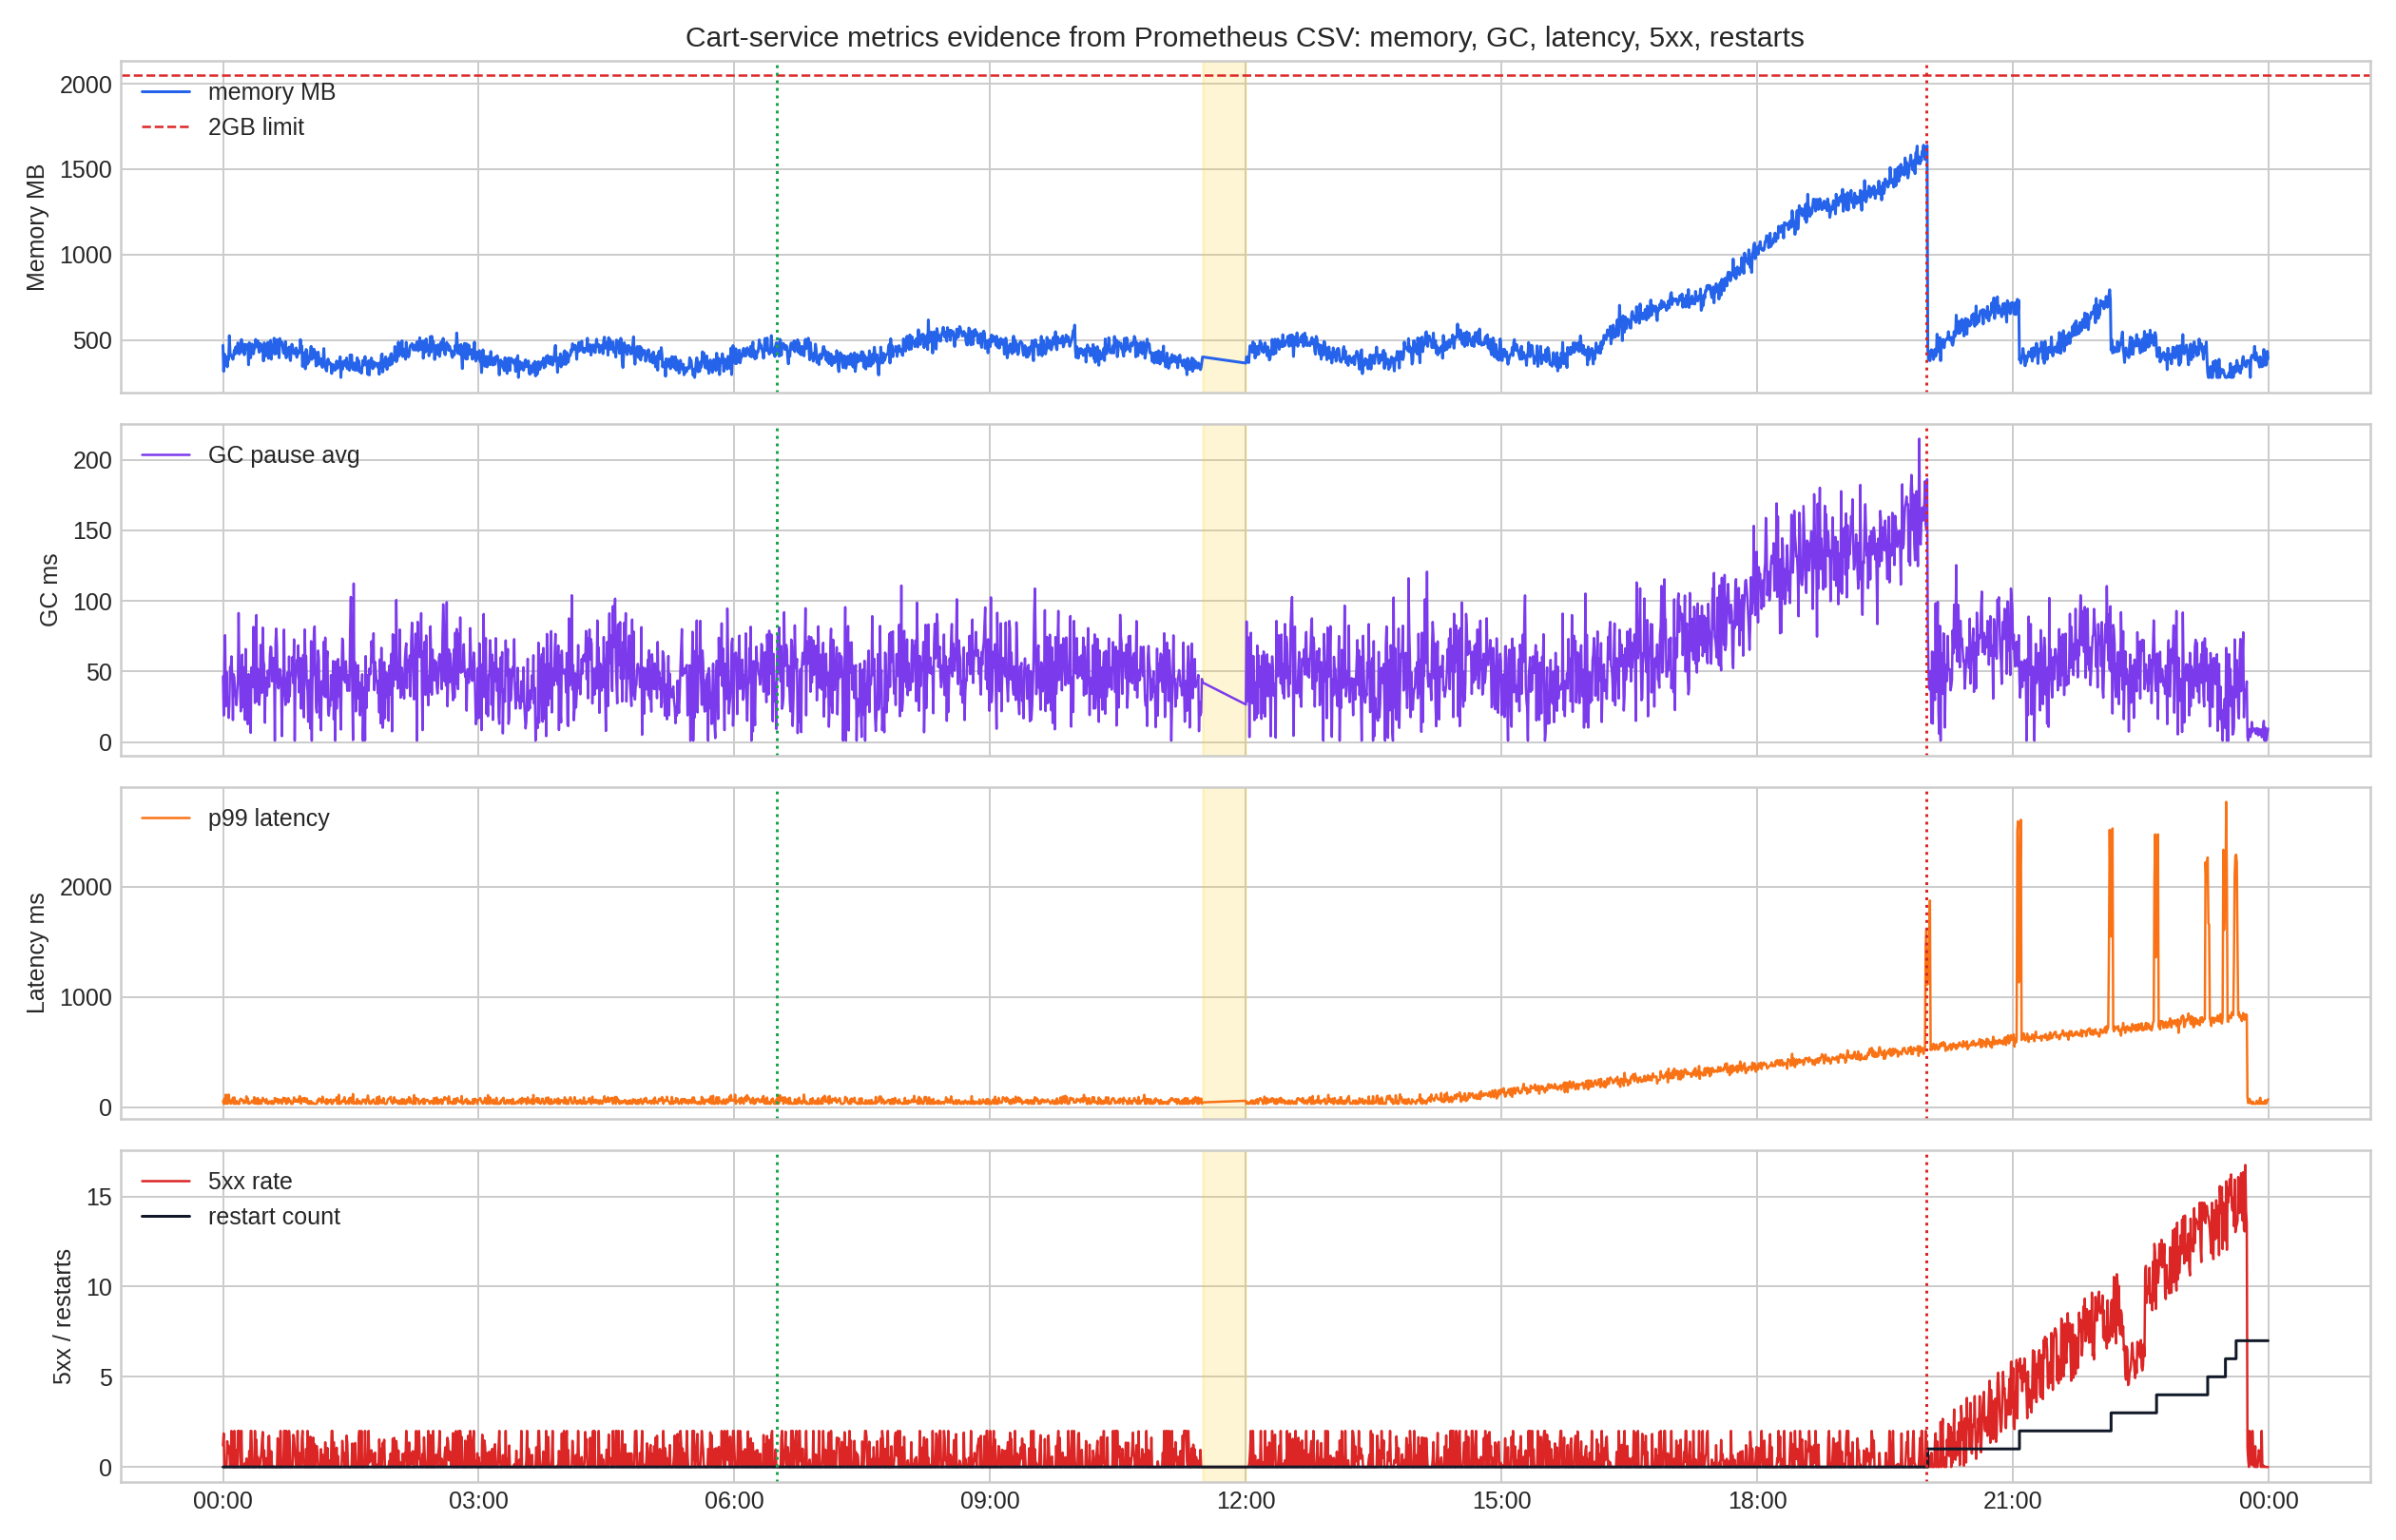

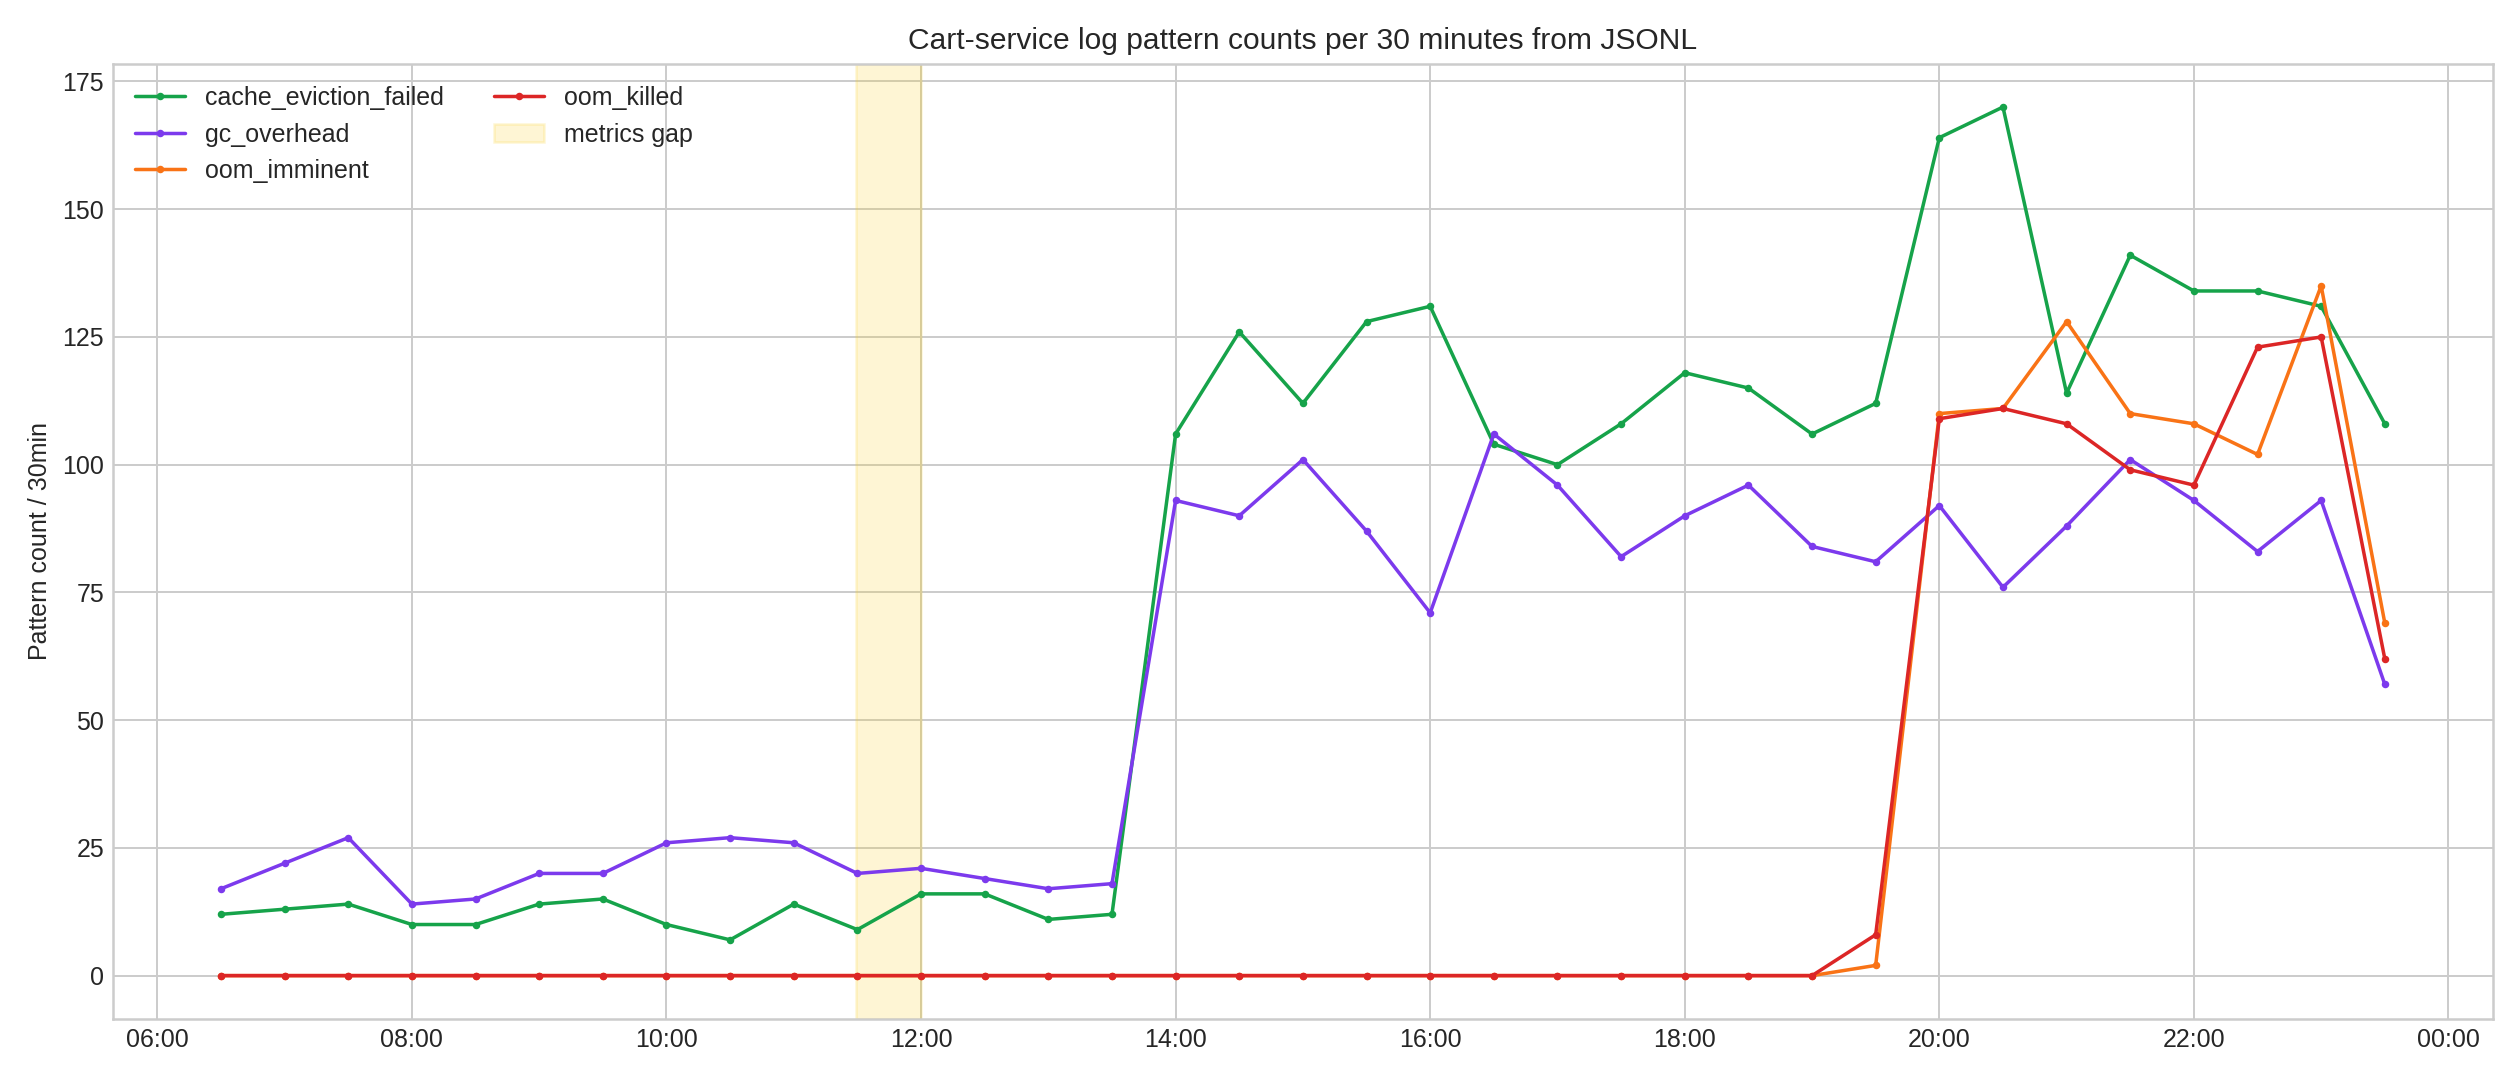

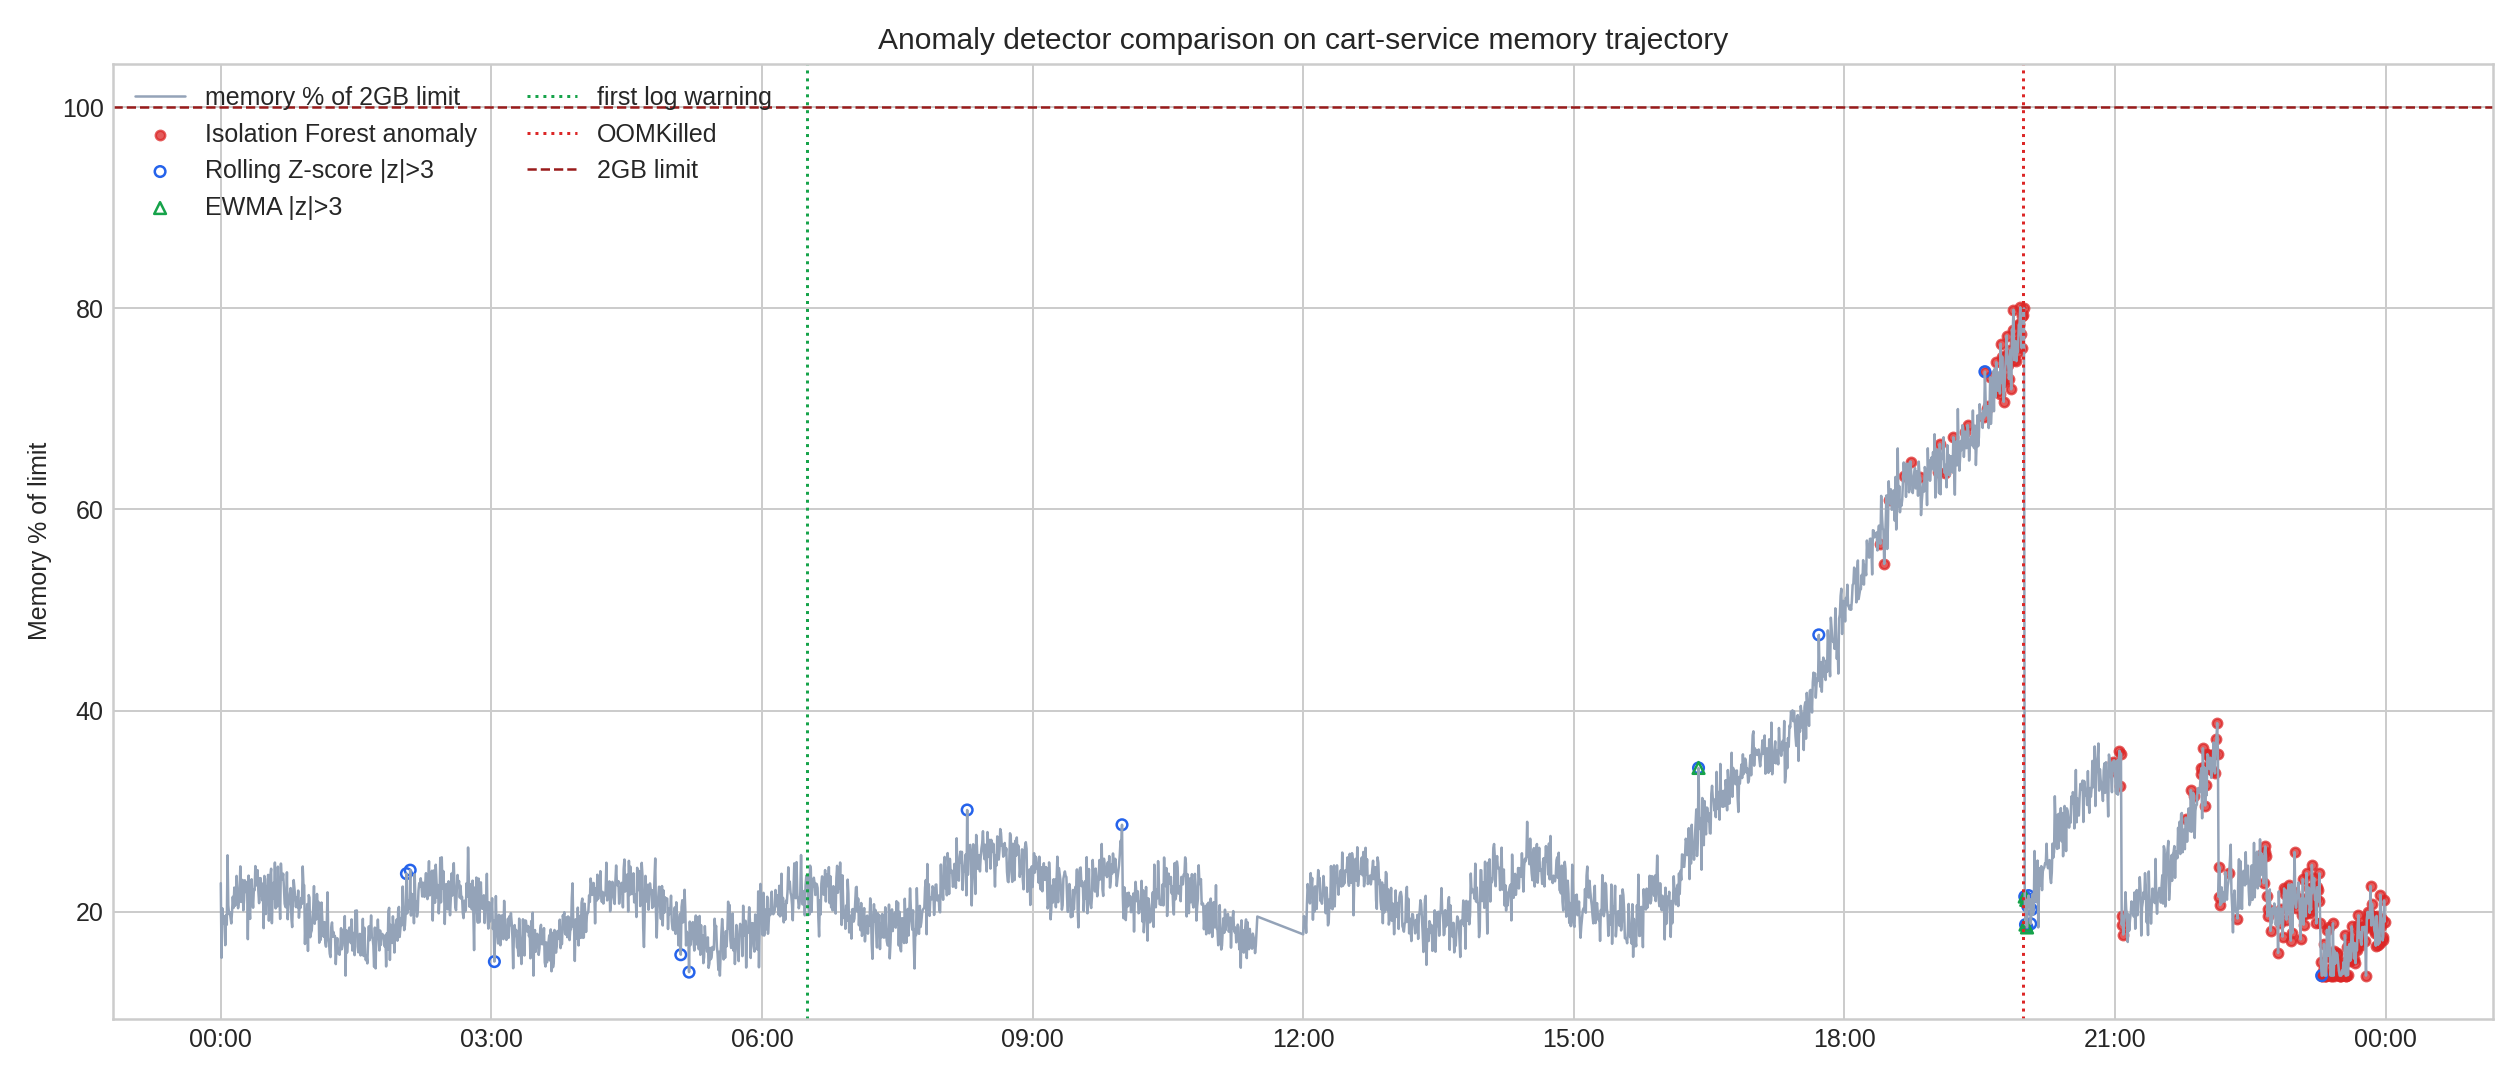

In [6]:
from IPython.display import Image, display

for name in [
    'cart_metrics_evidence.png',
    'cart_log_pattern_timeline.png',
    'cart_anomaly_detector_comparison.png',
]:
    display(Image(filename=str(root / 'reports/figures' / name)))

## 7. Findings Draft

The final findings file is generated from pipeline evidence and copied to `FINDINGS.md`.

In [7]:
print((root / 'FINDINGS.md').read_text())

# Incident Postmortem: vòng lặp restart của `cart-service`

Generated by `make analyze` thông qua `notebooks/analysis.ipynb`, notebook gọi `scripts/run_pipeline.py`.

## Tóm tắt điều tra

Nhóm dùng hướng điều tra **metric-first, log-backtrace**. Nghĩa là pipeline đọc metric trước, build feature, chạy detector trên metric, sau đó mới dùng log để giải thích và truy vết nguyên nhân. Cách viết này tránh nhầm rằng log `06:30` là do Z-score hoặc Isolation Forest phát hiện.

- **Isolation Forest** là detector metric đầu tiên bắt trạng thái degradation của `cart-service` lúc `2026-06-01T18:24:00+00:00`.
- **EWMA** phản ứng sớm hơn với thay đổi xu hướng do ưu tiên trọng số gần nhất.
- **Rolling Z-score** bắt pha memory spike/drop của incident quanh `2026-06-01T20:00:00+00:00`.
- Sau khi metric evidence chọn `cart-service`, bước log-backtrace tìm được evidence hỗ trợ sớm hơn: `ProductCatalogCache eviction failed` lúc `2026-06-01T06:30:08.687Z`, dòng `4235`.
- Log cũng xác nhận failure nhìn thấy 